# Sample Distance to Training Set: Why Do Some Seeds Memorize?

We analyze why some fixed noise seeds (sample indices) get memorized while others
remain erroneous or flicker between valid/invalid across training.

**Hypothesis**: Samples whose generated outputs land closer to the training set
(in Hamming / L2 distance) *before* the memorization transition are preferentially
pulled into exact memorization first.

**Sample trajectory categories**:
- `0 = stuck invalid` — never valid in the last 10% of training
- `1 = flickering` — valid some of the time (<80%) but never memorized
- `2 = valid novel` — consistently valid (≥80%) but not memorized
- `3 = memorized` — exactly matches a training sample at end

**Distance metrics**:
- Hamming: bit mismatches between quantized sample and nearest training sample
- L2: Euclidean distance in continuous (pre-quantized) activation space

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import os

matplotlib.rcParams.update({
    'pdf.fonttype': 42,
    'ps.fonttype':  42,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.size': 11,
})

SAVEROOT = (
    '/n/holylfs06/LABS/kempner_fellow_binxuwang/Users/binxuwang/'
    'DL_Projects/DiffusionParityLearning'
)
FIGDIR = '/n/home12/binxuwang/Github/DiffusionAttnConsistency/figures/dist_analysis'
os.makedirs(FIGDIR, exist_ok=True)

GROUP_SIZES = [2, 3, 4, 6, 9, 12, 18, 36]
EXP_NAMES = [f'DiT_mini_parity_N4096_D36_G{g}_even_rep2' for g in GROUP_SIZES]

# Trajectory state labels and colors
STATE_NAMES  = ['stuck invalid', 'flickering', 'valid novel', 'memorized']
STATE_COLORS = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']
STATE_MARKERS = ['x', 's', 'o', '*']
print('Setup done')

Setup done


## Section 1: Load data

In [2]:
def load_dist_data(exp_name):
    path = os.path.join(SAVEROOT, exp_name, 'evolution_analysis', 'dist_to_train.npz')
    d = np.load(path, allow_pickle=True)
    return {k: d[k] for k in d.files}

def load_evo_data(exp_name):
    path = os.path.join(SAVEROOT, exp_name, 'evolution_analysis', 'evolution_metrics.npz')
    d = np.load(path, allow_pickle=True)
    return {k: d[k] for k in d.files}

data   = {g: load_dist_data(EXP_NAMES[i]) for i, g in enumerate(GROUP_SIZES)}
evo    = {g: load_evo_data(EXP_NAMES[i])  for i, g in enumerate(GROUP_SIZES)}

for g in GROUP_SIZES:
    d = data[g]
    states = d['traj_state']
    print(f'G={g:2d}: stuck={( states==0).sum():4d} flicker={(states==1).sum():4d} '
          f'novel={(states==2).sum():4d} mem={(states==3).sum():4d}  '
          f'checkpoints={len(d["epochs_sub"])}')

G= 2: stuck=   0 flicker=   0 novel= 662 mem=1386  checkpoints=300
G= 3: stuck=   0 flicker=   4 novel=1238 mem= 806  checkpoints=300
G= 4: stuck=   0 flicker=   8 novel=1425 mem= 615  checkpoints=300
G= 6: stuck=   0 flicker=  61 novel=1452 mem= 535  checkpoints=300
G= 9: stuck= 591 flicker= 564 novel=  21 mem= 872  checkpoints=300
G=12: stuck= 601 flicker= 698 novel=  15 mem= 734  checkpoints=300
G=18: stuck=  61 flicker=1057 novel=  22 mem= 908  checkpoints=300
G=36: stuck=   1 flicker=1220 novel=  64 mem= 763  checkpoints=300


In [34]:
# Plot keys and shapes for 'data' and 'evo' for the first group as an example

g0 = GROUP_SIZES[0]
print(f"First GROUP_SIZE: {g0}")
print("\n== Keys and shapes in 'data' ==")
for k, v in data[g0].items():
    if hasattr(v, "shape"):
        print(f"  {k:16s}: shape={v.shape}")
    else:
        print(f"  {k:16s}: type={type(v)}")
print("\n== Keys and shapes in 'evo' ==")
for k, v in evo[g0].items():
    if hasattr(v, "shape"):
        print(f"  {k:16s}: shape={v.shape}")
    else:
        print(f"  {k:16s}: type={type(v)}")

First GROUP_SIZE: 2

== Keys and shapes in 'data' ==
  exp_name        : shape=(1,)
  epochs_sub      : shape=(300,)
  stride          : shape=()
  D               : shape=()
  N_train         : shape=()
  nearest_hamming : shape=(300, 2048)
  nearest_l2      : shape=(300, 2048)
  nearest_idx_ham : shape=(300, 2048)
  nearest_idx_l2  : shape=(300, 2048)
  traj_state      : shape=(2048,)
  first_mem_ep    : shape=(2048,)
  first_valid_ep  : shape=(2048,)
  flicker_score   : shape=(2048,)

== Keys and shapes in 'evo' ==
  epochs          : shape=(1499,)
  exp_name        : shape=(1,)
  ambig_thresh    : shape=()
  change_rate     : shape=(1498,)
  bit_change_rate : shape=(1498, 36)
  n_bits_changed  : shape=(1498, 2048)
  is_valid        : shape=(1499, 2048)
  is_mem          : shape=(1499, 2048)
  mean_confidence : shape=(1499, 2048)
  has_ambiguous   : shape=(1499, 2048)
  ambig_count     : shape=(1499, 2048)
  arrival_epochs  : shape=(4096,)


## Section 2: Hamming distance trajectories by trajectory state

For each G, plot mean nearest-Hamming distance over training steps, split by final trajectory state.

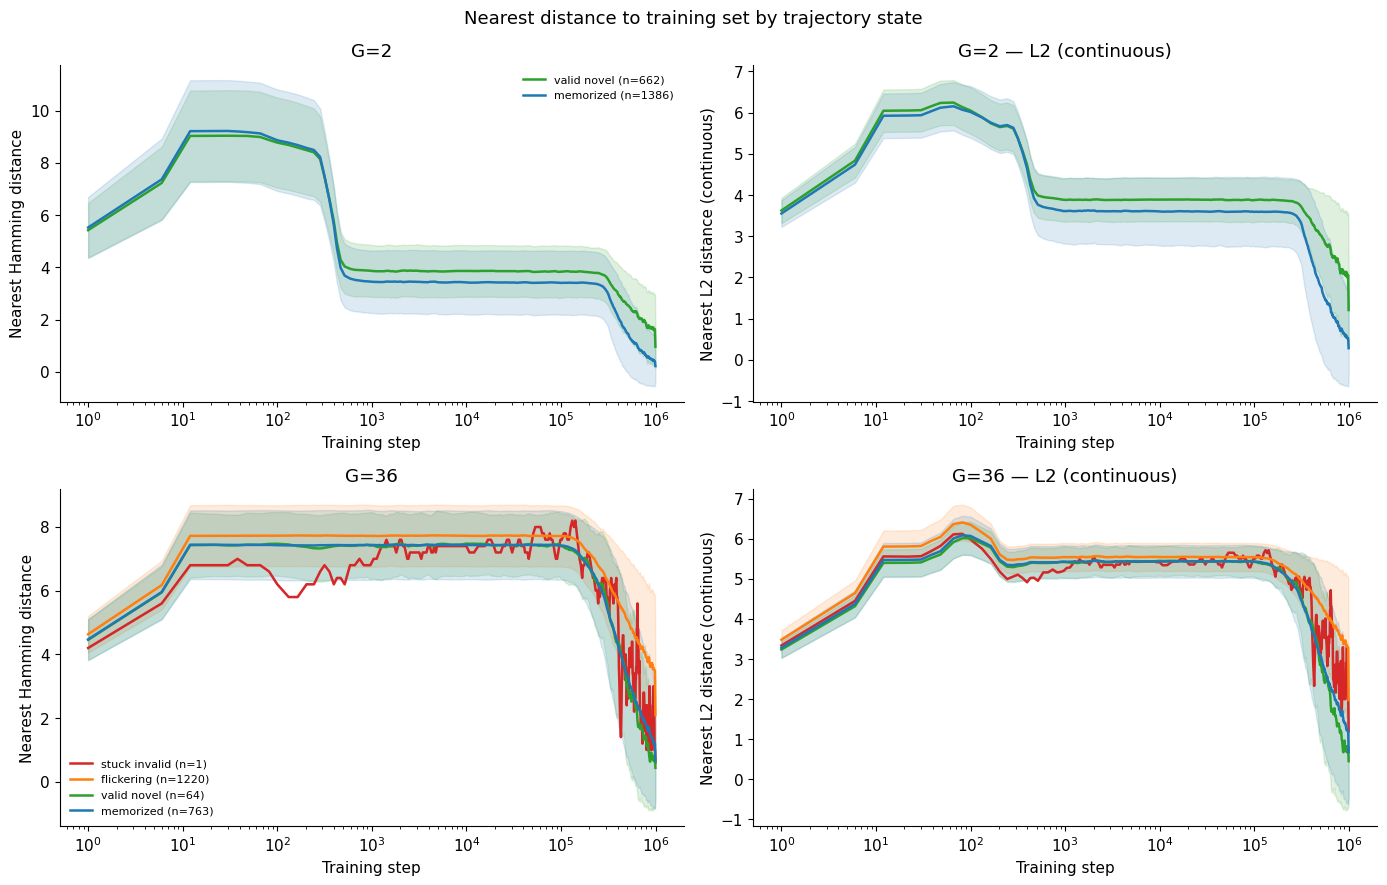

In [8]:
def plot_hamming_by_state(g, ax_ham, ax_l2=None, smooth=5):
    d = data[g]
    epochs_sub = d['epochs_sub']
    ham        = d['nearest_hamming']  # (T_sub, N)
    l2         = d['nearest_l2']       # (T_sub, N)
    states     = d['traj_state']       # (N,)

    for s in range(4):
        mask = states == s
        if mask.sum() == 0:
            continue
        h_mean = ham[:, mask].mean(axis=1)
        h_std  = ham[:, mask].std(axis=1)
        if smooth > 1:
            kernel = np.ones(smooth) / smooth
            h_mean = np.convolve(h_mean, kernel, mode='same')
            h_std  = np.convolve(h_std,  kernel, mode='same')
        ax_ham.plot(epochs_sub, h_mean, color=STATE_COLORS[s],
                    label=f'{STATE_NAMES[s]} (n={mask.sum()})', lw=1.8)
        ax_ham.fill_between(epochs_sub, h_mean - h_std, h_mean + h_std,
                             color=STATE_COLORS[s], alpha=0.15)

        if ax_l2 is not None:
            l_mean = l2[:, mask].mean(axis=1)
            l_std  = l2[:, mask].std(axis=1)
            if smooth > 1:
                l_mean = np.convolve(l_mean, kernel, mode='same')
                l_std  = np.convolve(l_std,  kernel, mode='same')
            ax_l2.plot(epochs_sub, l_mean, color=STATE_COLORS[s], lw=1.8)
            ax_l2.fill_between(epochs_sub, l_mean - l_std, l_mean + l_std,
                                color=STATE_COLORS[s], alpha=0.15)

    ax_ham.set_xscale('log')
    ax_ham.set_xlabel('Training step')
    ax_ham.set_ylabel('Nearest Hamming distance')
    ax_ham.set_title(f'G={g}')
    ax_ham.legend(fontsize=8, frameon=False)

    if ax_l2 is not None:
        ax_l2.set_xscale('log')
        ax_l2.set_xlabel('Training step')
        ax_l2.set_ylabel('Nearest L2 distance (continuous)')


# Show G=2 and G=36 as detailed examples
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for i, g in enumerate([2, 36]):
    plot_hamming_by_state(g, axes[i, 0], axes[i, 1])
    axes[i, 1].set_title(f'G={g} — L2 (continuous)')

fig.suptitle('Nearest distance to training set by trajectory state', fontsize=13)
fig.tight_layout()
fig.savefig(f'{FIGDIR}/hamming_by_state_G2_G36.pdf', bbox_inches='tight')
plt.show()

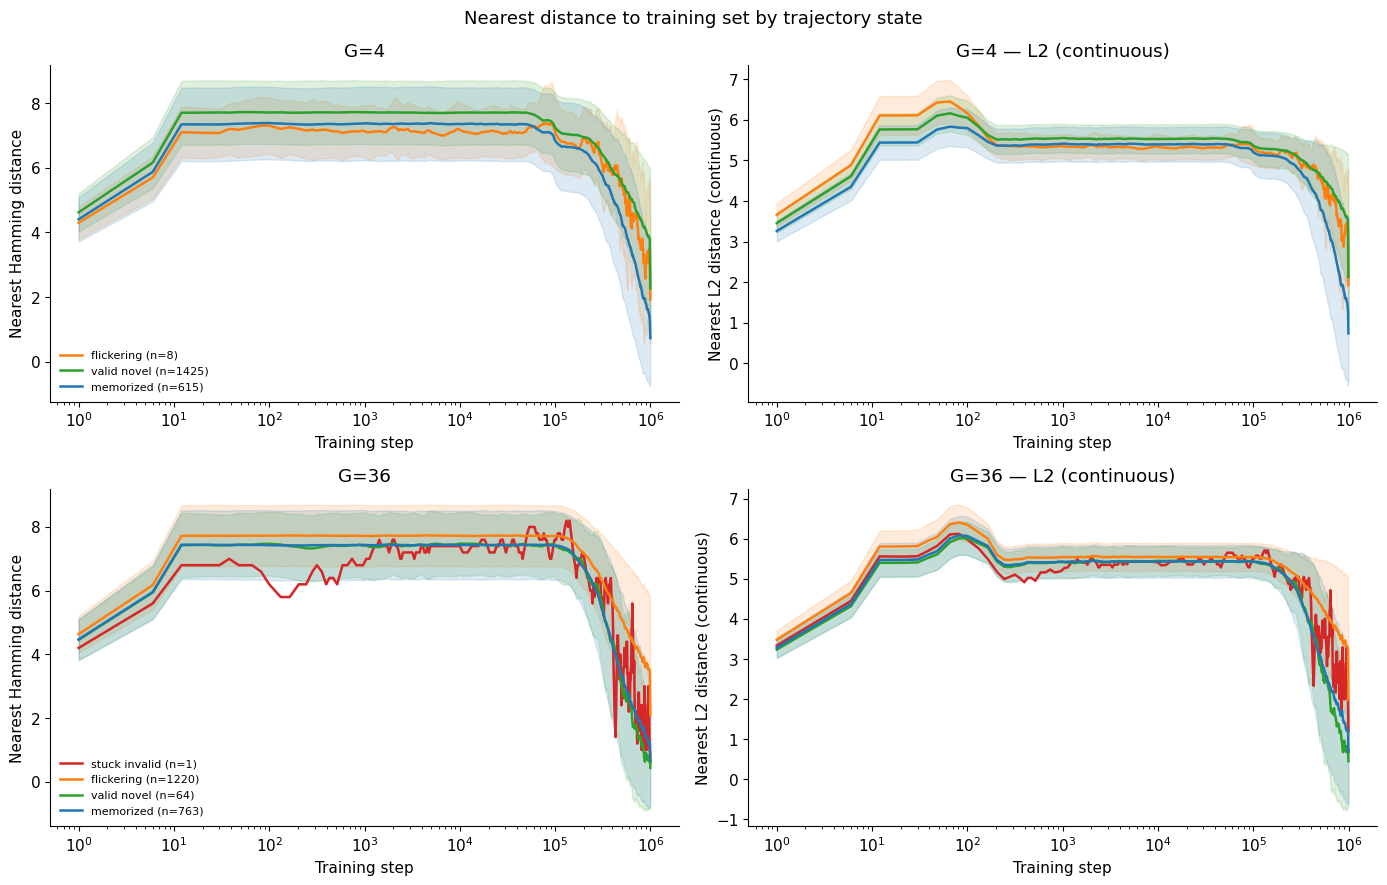

In [10]:
# Show G=2 and G=36 as detailed examples
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for i, g in enumerate([4, 36]):
    plot_hamming_by_state(g, axes[i, 0], axes[i, 1])
    axes[i, 1].set_title(f'G={g} — L2 (continuous)')

fig.suptitle('Nearest distance to training set by trajectory state', fontsize=13)
fig.tight_layout()
fig.savefig(f'{FIGDIR}/hamming_by_state_G4_G36.pdf', bbox_inches='tight')
plt.show()

In [ ]:
# Show G=2 and G=36 as detailed examples
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for i, g in enumerate([4, 36]):
    plot_hamming_by_state(g, axes[i, 0], axes[i, 1])
    axes[i, 1].set_title(f'G={g} — L2 (continuous)')

fig.suptitle('Nearest distance to training set by trajectory state', fontsize=13)
fig.tight_layout()
fig.savefig(f'{FIGDIR}/hamming_by_state_G4_G36.pdf', bbox_inches='tight')
plt.show()

In [ ]:
# 2×4 grid: all 8 G values, Hamming only
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, g in zip(axes.flat, GROUP_SIZES):
    plot_hamming_by_state(g, ax, smooth=3)

fig.suptitle('Nearest Hamming distance to training set — all G values', fontsize=13)
fig.tight_layout()
fig.savefig(f'{FIGDIR}/hamming_by_state_allG.pdf', bbox_inches='tight')
plt.show()

## Section 3: Time-to-memorize vs initial Hamming distance

For memorized samples: does smaller initial (or pre-transition) Hamming distance predict earlier memorization?

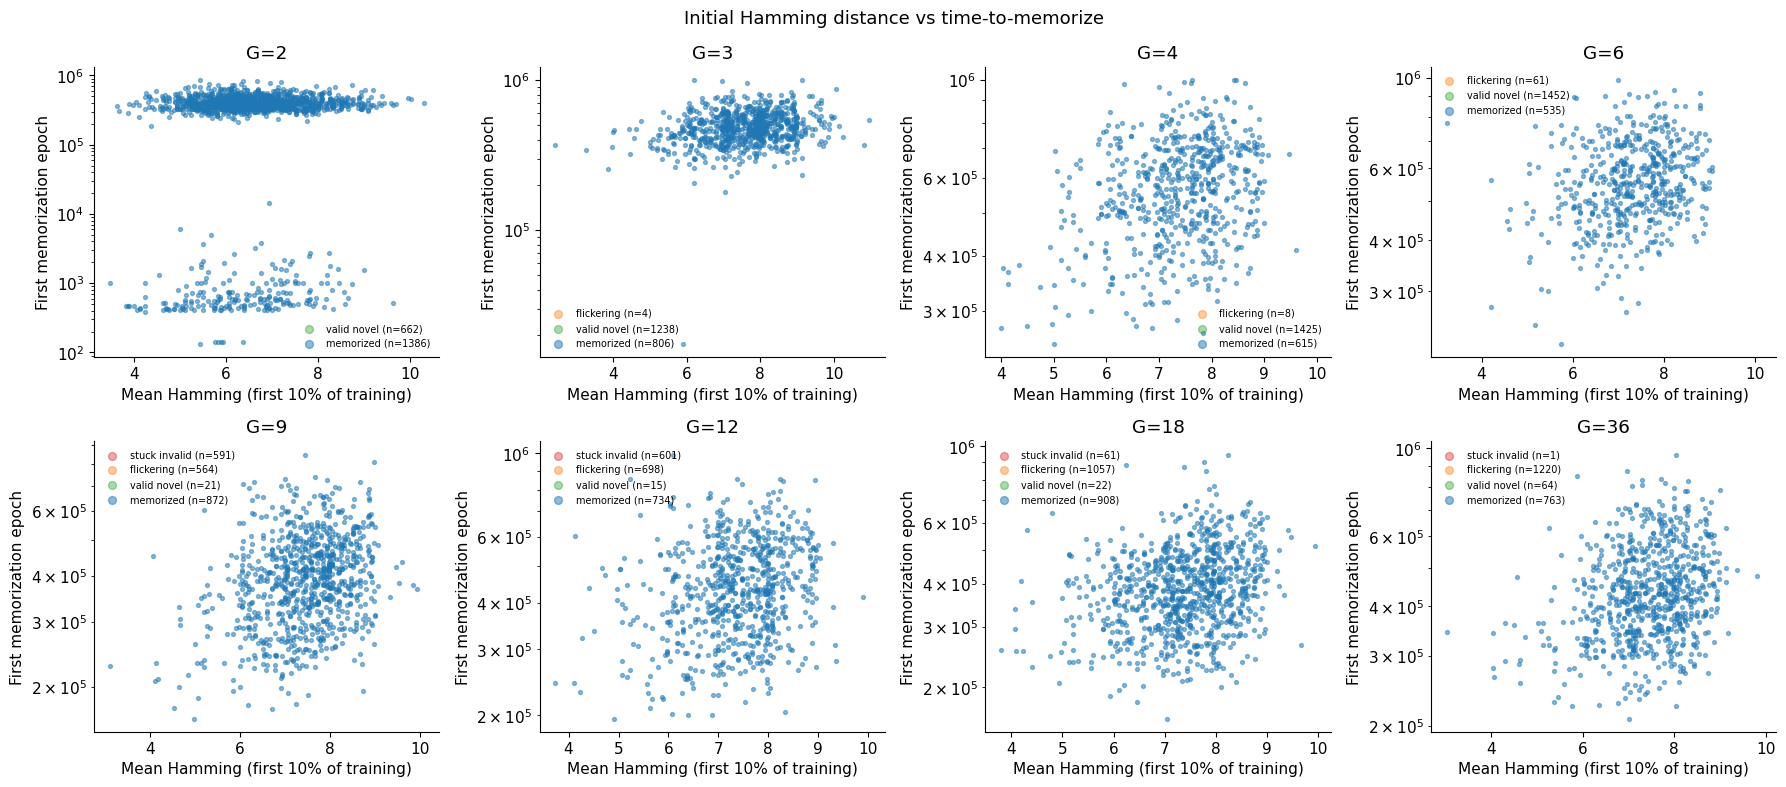

In [ ]:
def get_early_hamming(g, epoch_frac=0.1):
    """Return mean Hamming in first epoch_frac of the trajectory for each sample."""
    d = data[g]
    epochs_sub = d['epochs_sub']
    ham        = d['nearest_hamming']  # (T_sub, N)
    n_early    = max(1, int(len(epochs_sub) * epoch_frac))
    return ham[:n_early].mean(axis=0)  # (N,)

def get_hamming_interval(g, epoch_interval=(0.5,0.7)):
    """Return mean Hamming in first epoch_frac of the trajectory for each sample."""
    d = data[g]
    epochs_sub = d['epochs_sub']
    ham        = d['nearest_hamming']  # (T_sub, N)
    n_early    = max(1, int(len(epochs_sub) * epoch_interval[0]))
    n_late     = max(1, int(len(epochs_sub) * epoch_interval[1]))
    print(epochs_sub[n_early], epochs_sub[n_late], "Interval:", epoch_interval, "idx:", n_early, n_late)
    return ham[n_early:n_late].mean(axis=0)  # (N,)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for ax, g in zip(axes.flat, GROUP_SIZES):
    d          = data[g]
    states     = d['traj_state']
    first_mem  = d['first_mem_ep']   # (N,)
    early_ham  = get_early_hamming(g, epoch_frac=0.1)
    # interval_ham = get_hamming_interval(g, epoch_interval=(0.5,0.7))

    for s in range(4):
        mask = states == s
        if mask.sum() == 0:
            continue
        ep  = first_mem[mask]
        ham = early_ham[mask]
        # For non-memorized, plot as jittered points at right edge
        if s == 3:  # memorized: real scatter
            valid_mask = ep > 0
            ax.scatter(ham[valid_mask], ep[valid_mask],
                       c=STATE_COLORS[s], s=8, alpha=0.5,
                       label=f'{STATE_NAMES[s]} (n={valid_mask.sum()})')
        else:
            ax.scatter(ham + np.random.randn(mask.sum()) * 0.2,
                       np.full(mask.sum(), -1),   # sentinel
                       c=STATE_COLORS[s], s=8, alpha=0.4,
                       label=f'{STATE_NAMES[s]} (n={mask.sum()})')

    ax.set_xlabel('Mean Hamming (first 10% of training)')
    ax.set_ylabel('First memorization epoch')
    ax.set_yscale('log')
    ax.set_title(f'G={g}')
    ax.legend(fontsize=7, frameon=False, markerscale=2)

fig.suptitle('Initial Hamming distance vs time-to-memorize', fontsize=13)
fig.tight_layout()
fig.savefig(f'{FIGDIR}/hamming_vs_mem_time.pdf', bbox_inches='tight')
plt.show()

93520 542368 Interval: (0.4, 0.7) idx: 120 210
93520 542368 Interval: (0.4, 0.7) idx: 120 210
93520 542368 Interval: (0.4, 0.7) idx: 120 210
93520 542368 Interval: (0.4, 0.7) idx: 120 210
93520 542368 Interval: (0.4, 0.7) idx: 120 210
93520 542368 Interval: (0.4, 0.7) idx: 120 210
93520 542368 Interval: (0.4, 0.7) idx: 120 210
93520 542368 Interval: (0.4, 0.7) idx: 120 210


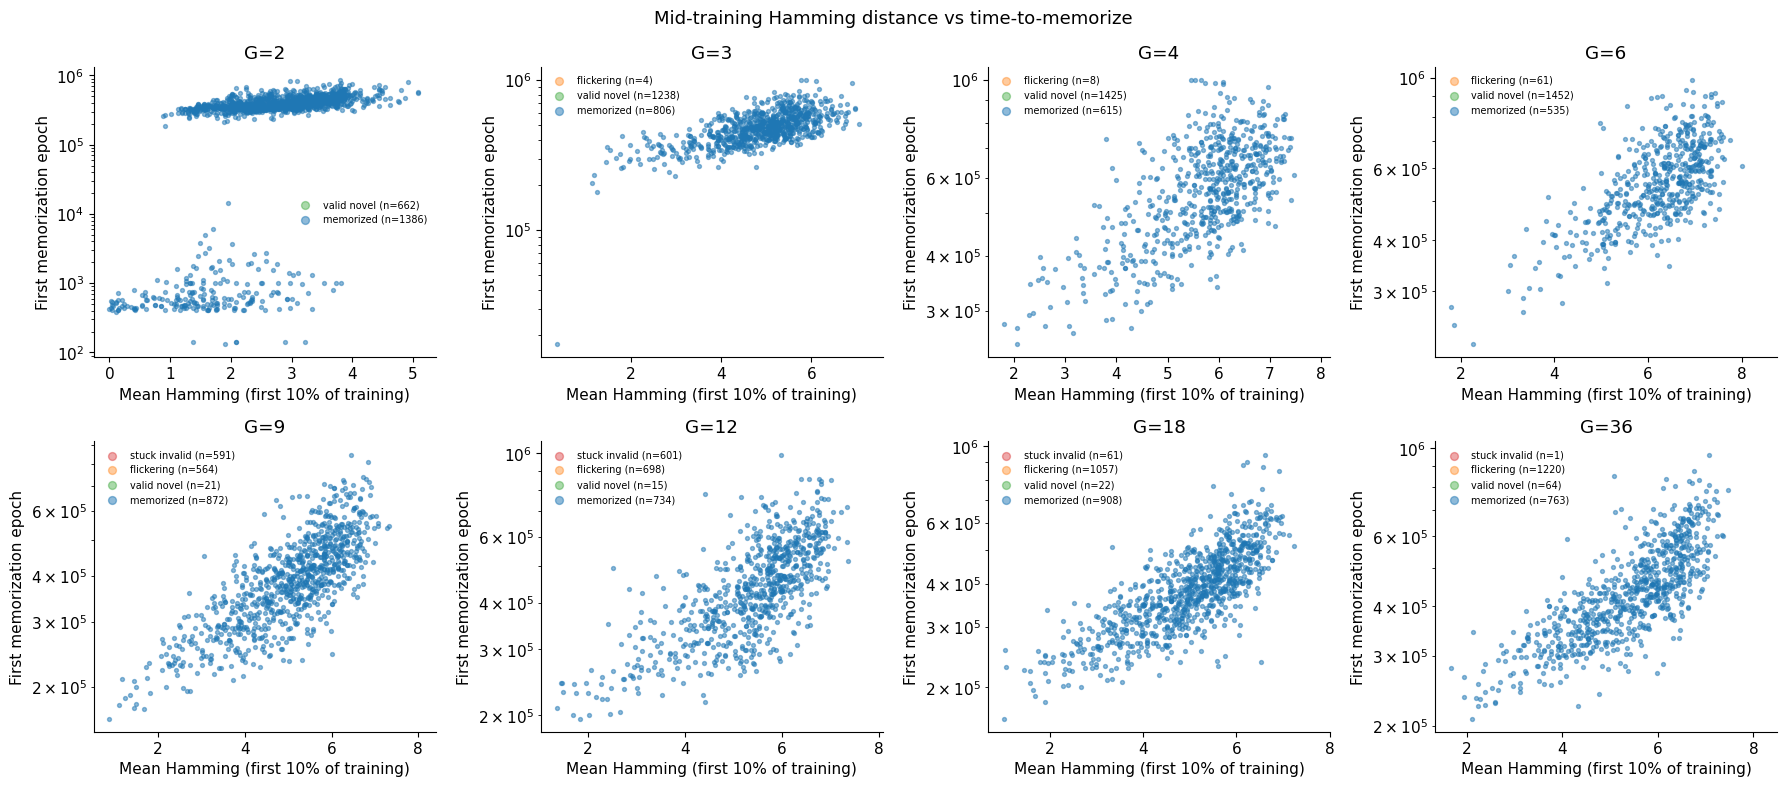

In [16]:


def get_hamming_interval(g, epoch_interval=(0.5,0.7)):
    """Return mean Hamming in first epoch_frac of the trajectory for each sample."""
    d = data[g]
    epochs_sub = d['epochs_sub']
    ham        = d['nearest_hamming']  # (T_sub, N)
    n_early    = max(1, int(len(epochs_sub) * epoch_interval[0]))
    n_late     = max(1, int(len(epochs_sub) * epoch_interval[1]))
    print(epochs_sub[n_early], epochs_sub[n_late], "Interval:", epoch_interval, "idx:", n_early, n_late)
    return ham[n_early:n_late].mean(axis=0)  # (N,)


fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for ax, g in zip(axes.flat, GROUP_SIZES):
    d          = data[g]
    states     = d['traj_state']
    first_mem  = d['first_mem_ep']   # (N,)
    # early_ham  = get_early_hamming(g, epoch_frac=0.1)
    interval_ham = get_hamming_interval(g, epoch_interval=(0.4,0.7))

    for s in range(4):
        mask = states == s
        if mask.sum() == 0:
            continue
        ep  = first_mem[mask]
        ham = interval_ham[mask]
        # For non-memorized, plot as jittered points at right edge
        if s == 3:  # memorized: real scatter
            valid_mask = ep > 0
            ax.scatter(ham[valid_mask], ep[valid_mask],
                       c=STATE_COLORS[s], s=8, alpha=0.5,
                       label=f'{STATE_NAMES[s]} (n={valid_mask.sum()})')
        else:
            ax.scatter(ham + np.random.randn(mask.sum()) * 0.2,
                       np.full(mask.sum(), -1),   # sentinel
                       c=STATE_COLORS[s], s=8, alpha=0.4,
                       label=f'{STATE_NAMES[s]} (n={mask.sum()})')

    ax.set_xlabel('Mean Hamming (first 10% of training)')
    ax.set_ylabel('First memorization epoch')
    ax.set_yscale('log')
    ax.set_title(f'G={g}')
    ax.legend(fontsize=7, frameon=False, markerscale=2)

fig.suptitle('Mid-training Hamming distance vs time-to-memorize', fontsize=13)
fig.tight_layout()
fig.savefig(f'{FIGDIR}/hamming_vs_mem_time.pdf', bbox_inches='tight')
plt.show()

## Section 4: Hamming distance distribution at key epochs

Violin plots showing nearest Hamming distribution split by trajectory state at several training snapshots.

In [ ]:
def hamming_violin_at_epoch(g, target_epoch_fracs=(0.05, 0.2, 0.5, 0.9), ax=None):
    d = data[g]
    epochs_sub = d['epochs_sub']
    ham   = d['nearest_hamming']  # (T_sub, N)
    states = d['traj_state']       # (N,)

    T_sub = len(epochs_sub)
    t_indices = [int(f * T_sub) for f in target_epoch_fracs]
    t_indices = [min(t, T_sub - 1) for t in t_indices]

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))

    present_states = [s for s in range(4) if (states == s).sum() > 0]
    n_states = len(present_states)
    n_epochs = len(t_indices)
    spacing  = n_states + 1

    for epoch_i, t_idx in enumerate(t_indices):
        for state_i, s in enumerate(present_states):
            mask = states == s
            vals = ham[t_idx, mask].astype(float)
            x_pos = epoch_i * spacing + state_i
            parts = ax.violinplot([vals], positions=[x_pos],
                                   showmedians=True, widths=0.8)
            for pc in parts['bodies']:
                pc.set_facecolor(STATE_COLORS[s])
                pc.set_alpha(0.6)
            parts['cmedians'].set_color(STATE_COLORS[s])
            parts['cmins'].set_color(STATE_COLORS[s])
            parts['cmaxes'].set_color(STATE_COLORS[s])
            parts['cbars'].set_color(STATE_COLORS[s])

    # x-tick labels: epoch fractions
    tick_pos   = [i * spacing + (n_states - 1) / 2 for i in range(n_epochs)]
    tick_labels = [f'ep={epochs_sub[t]:,.0f}' for t in t_indices]
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_labels, rotation=15, ha='right')
    ax.set_ylabel('Nearest Hamming distance')
    ax.set_title(f'G={g}')

    legend_els = [Line2D([0], [0], color=STATE_COLORS[s], lw=4,
                          label=f'{STATE_NAMES[s]} (n={(states==s).sum()})')
                  for s in present_states]
    ax.legend(handles=legend_els, fontsize=8, frameon=False)


# Show for G=6 (interesting mix of states)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, g in zip(axes, [6, 18]):
    hamming_violin_at_epoch(g, ax=ax)
fig.suptitle('Nearest Hamming distance distribution at key epochs', fontsize=13)
fig.tight_layout()
fig.savefig(f'{FIGDIR}/hamming_violin_G6_G18.pdf', bbox_inches='tight')
plt.show()

## Section 5: Per-sample trajectories — memorized vs flickering

Show individual sample Hamming trajectories alongside valid/invalid state for a selection of samples.

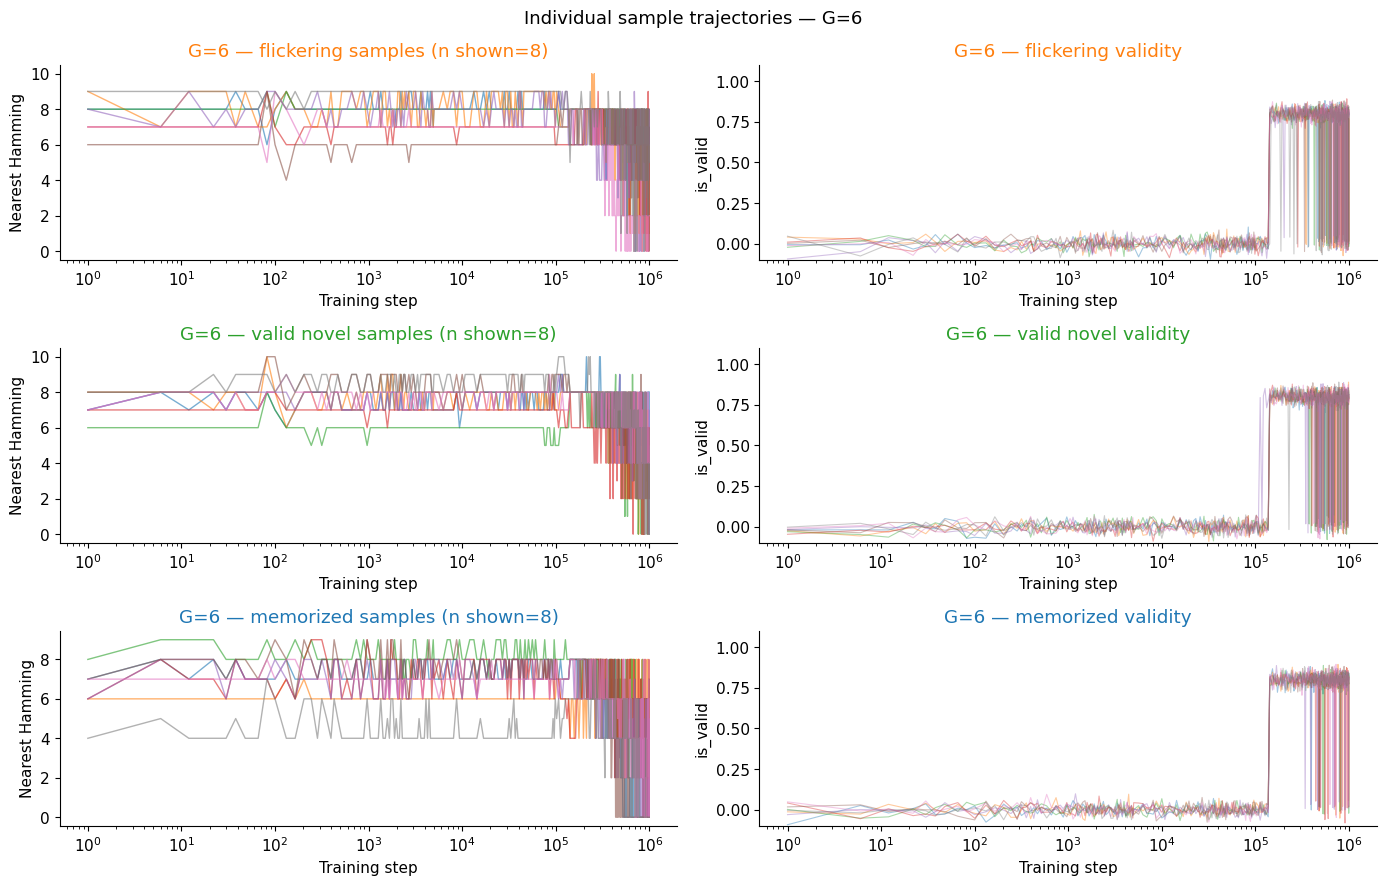

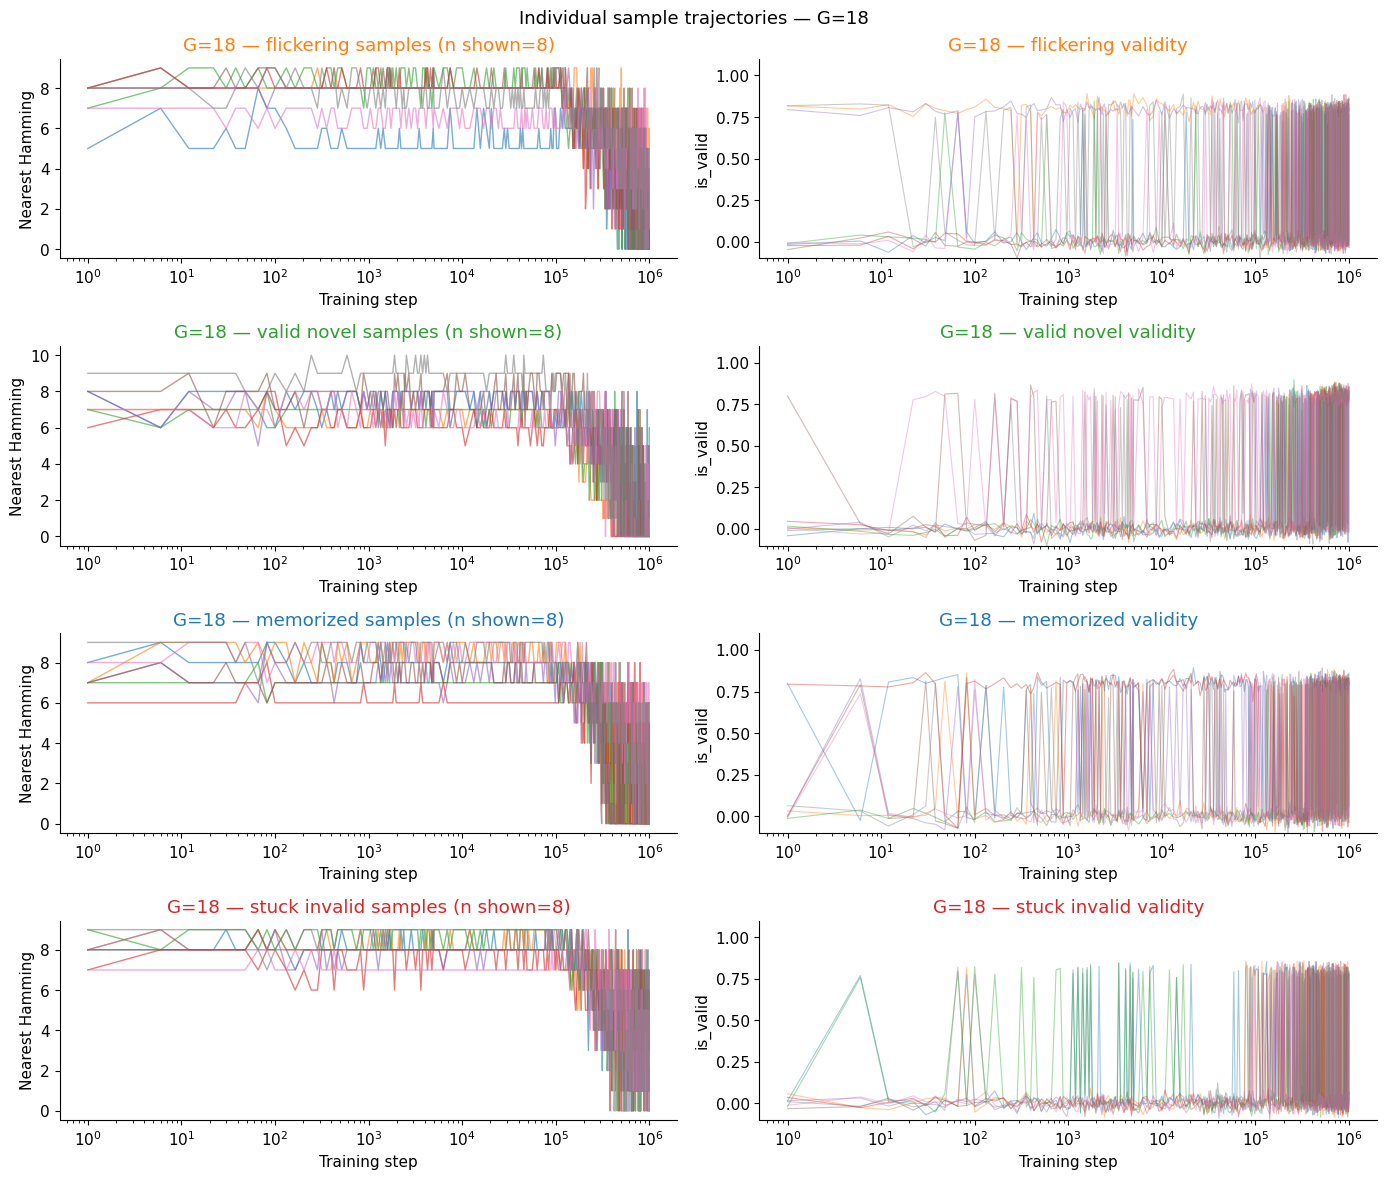

In [17]:
def plot_sample_trajectories(g, n_per_state=8, seed=42):
    rng = np.random.default_rng(seed)
    d   = data[g]
    ev  = evo[g]

    epochs_sub = d['epochs_sub']
    ham        = d['nearest_hamming']  # (T_sub, N)
    l2         = d['nearest_l2']       # (T_sub, N)
    states     = d['traj_state']       # (N,)

    epochs_full = ev['epochs']     # (T,)
    is_valid    = ev['is_valid']   # (T, N)
    is_mem      = ev['is_mem']     # (T, N)

    # Map epochs_sub to nearest index in epochs_full for valid/mem overlay
    # (just use is_valid at every stride-th checkpoint)
    stride = int(d['stride'])
    is_valid_sub = is_valid[::stride][:len(epochs_sub)]   # (T_sub, N)
    is_mem_sub   = is_mem[::stride][:len(epochs_sub)]     # (T_sub, N)

    # Select states to show (flicker and mem are most interesting)
    states_to_show = [s for s in [1, 2, 3, 0] if (states == s).sum() >= 2]

    n_rows = len(states_to_show)
    fig, axes = plt.subplots(n_rows, 2, figsize=(14, 3 * n_rows))
    if n_rows == 1:
        axes = axes[np.newaxis, :]

    for row, s in enumerate(states_to_show):
        mask  = np.where(states == s)[0]
        chosen = rng.choice(mask, size=min(n_per_state, len(mask)), replace=False)

        ax_ham = axes[row, 0]
        ax_val = axes[row, 1]

        for idx in chosen:
            ax_ham.plot(epochs_sub, ham[:, idx], alpha=0.6, lw=1.0)
            # valid/mem as colored background stripes
            valid_t = is_valid_sub[:, idx].astype(float)
            mem_t   = is_mem_sub[:, idx].astype(float)
            ax_val.plot(epochs_sub, valid_t * 0.8 + np.random.randn(len(epochs_sub)) * 0.03,
                        alpha=0.4, lw=0.8)

        ax_ham.set_xscale('log')
        ax_ham.set_xlabel('Training step')
        ax_ham.set_ylabel('Nearest Hamming')
        ax_ham.set_title(f'G={g} — {STATE_NAMES[s]} samples (n shown={len(chosen)})',
                          color=STATE_COLORS[s])

        ax_val.set_xscale('log')
        ax_val.set_xlabel('Training step')
        ax_val.set_ylabel('is_valid')
        ax_val.set_ylim(-0.1, 1.1)
        ax_val.set_title(f'G={g} — {STATE_NAMES[s]} validity', color=STATE_COLORS[s])

    fig.suptitle(f'Individual sample trajectories — G={g}', fontsize=13)
    fig.tight_layout()
    fig.savefig(f'{FIGDIR}/sample_traj_G{g}.pdf', bbox_inches='tight')
    plt.show()


plot_sample_trajectories(g=6)
plot_sample_trajectories(g=18)

## Section 6: Memorization "gate" — Hamming threshold

A sample appears to memorize once it first reaches Hamming distance 0 (exact match).
Plot the fraction of samples at each Hamming distance value at different training stages.

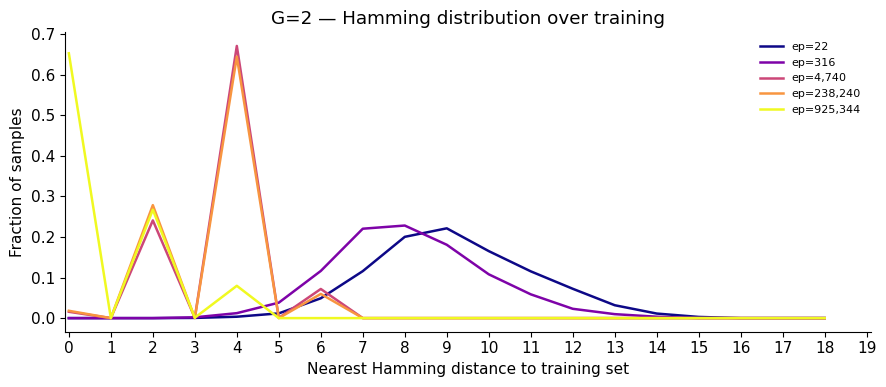

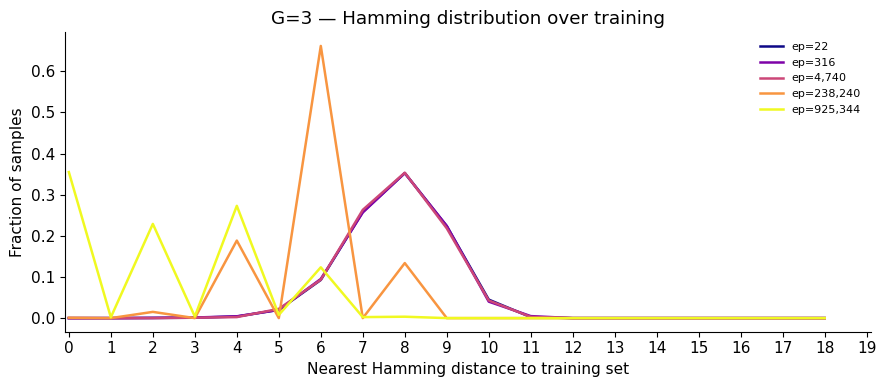

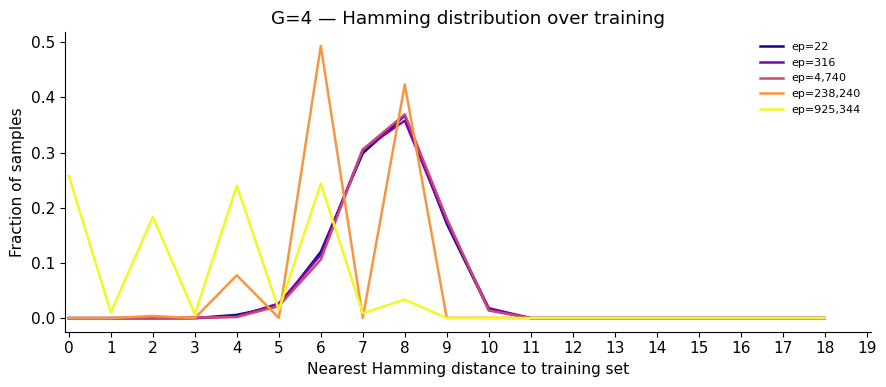

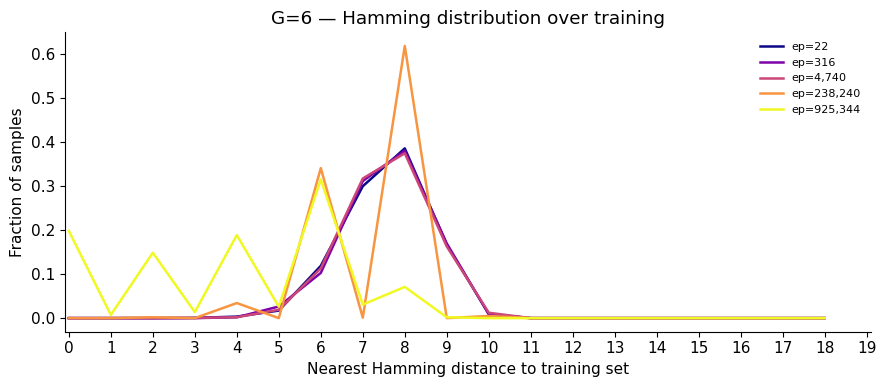

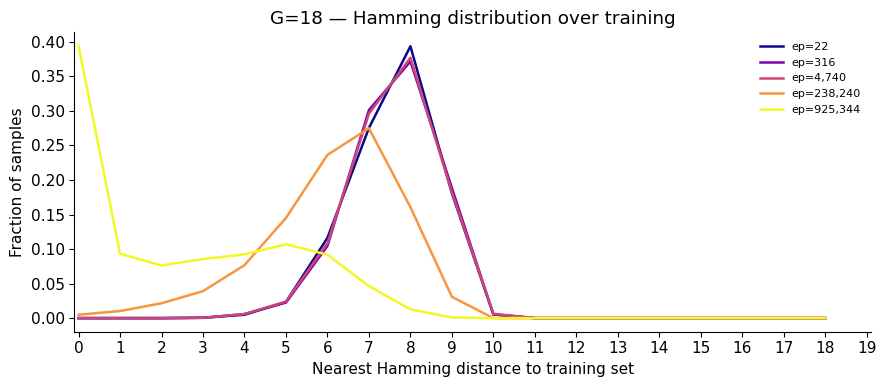

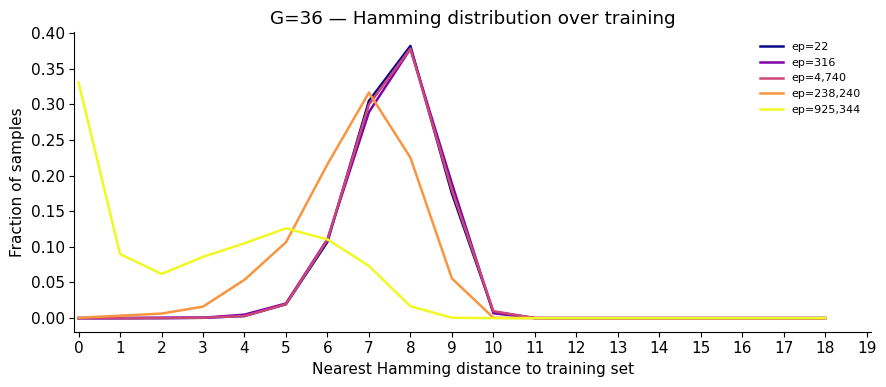

In [20]:
def hamming_hist_over_time(g, epoch_fracs=(0.01, 0.05, 0.2, 0.5, 0.95)):
    d = data[g]
    epochs_sub = d['epochs_sub']
    ham   = d['nearest_hamming']  # (T_sub, N)
    T_sub = len(epochs_sub)

    t_indices = [min(int(f * T_sub), T_sub - 1) for f in epoch_fracs]
    D         = int(d['D'])

    cmap   = plt.get_cmap('plasma')
    colors = [cmap(i / (len(t_indices) - 1)) for i in range(len(t_indices))]

    fig, ax = plt.subplots(figsize=(9, 4))
    for ti, t_idx in enumerate(t_indices):
        vals = ham[t_idx]
        bins = np.arange(0, D // 2 + 2) - 0.5
        counts, edges = np.histogram(vals, bins=bins)
        ax.plot((edges[:-1] + 0.5), counts / counts.sum(),
                color=colors[ti], lw=1.8,
                label=f'ep={epochs_sub[t_idx]:,.0f}')

    ax.set_xlabel('Nearest Hamming distance to training set')
    ax.set_ylabel('Fraction of samples')
    ax.set_title(f'G={g} — Hamming distribution over training')

    # Set x-axis ticks to integer values
    x_min = 0
    x_max = D // 2 + 1
    ax.set_xticks(np.arange(x_min, x_max + 1))
    ax.set_xlim(x_min - 0.1, x_max + 0.1)

    ax.legend(fontsize=8, frameon=False)
    fig.tight_layout()
    fig.savefig(f'{FIGDIR}/hamming_hist_G{g}.pdf', bbox_inches='tight')
    plt.show()


for g in [2, 3, 4, 6, 18, 36]:
    hamming_hist_over_time(g)

## Section 7: Hamming heatmap — step × sample, sorted by memorization time

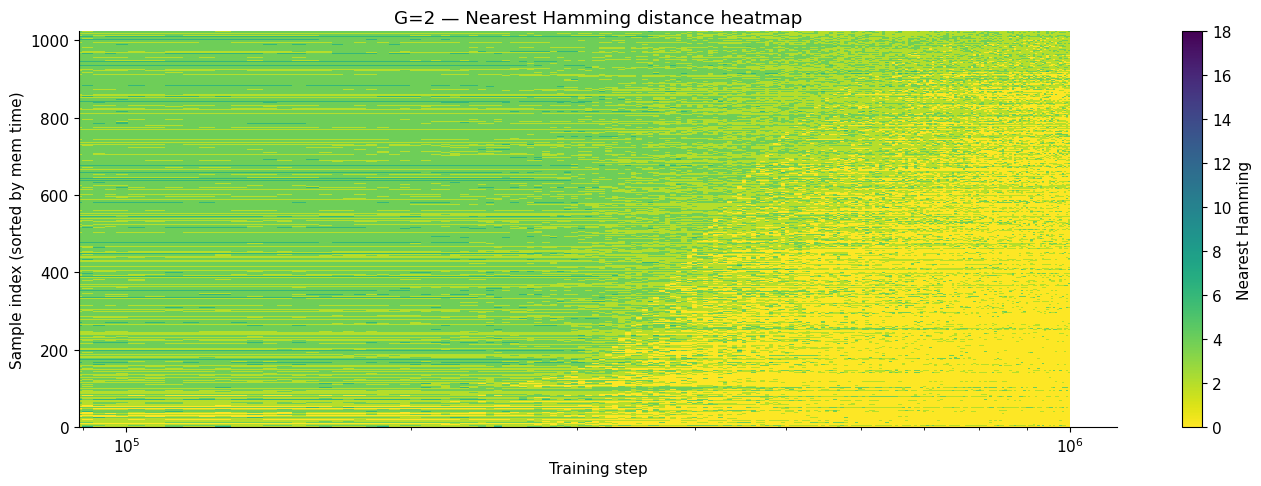

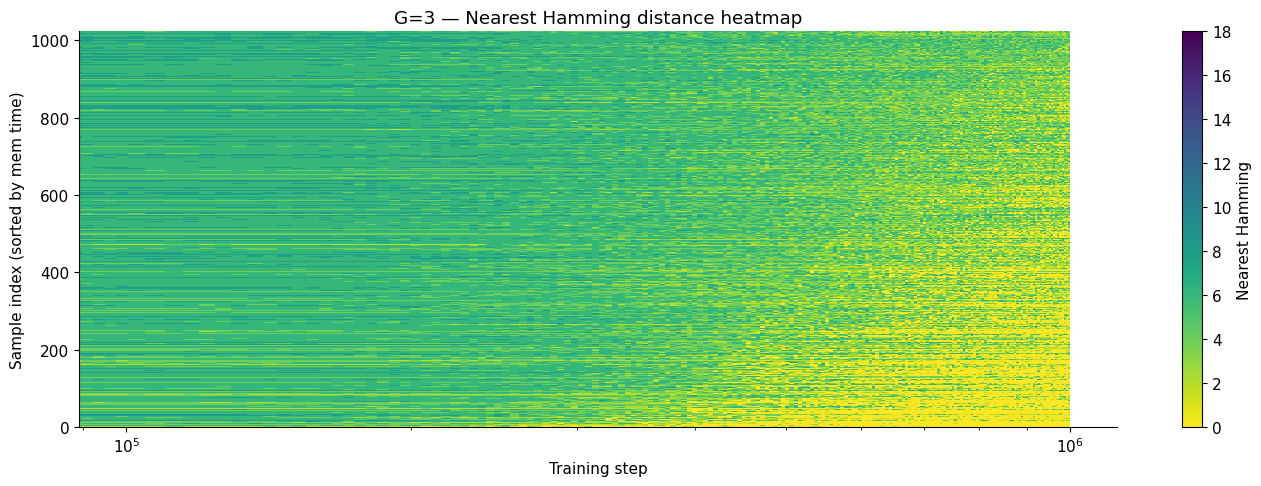

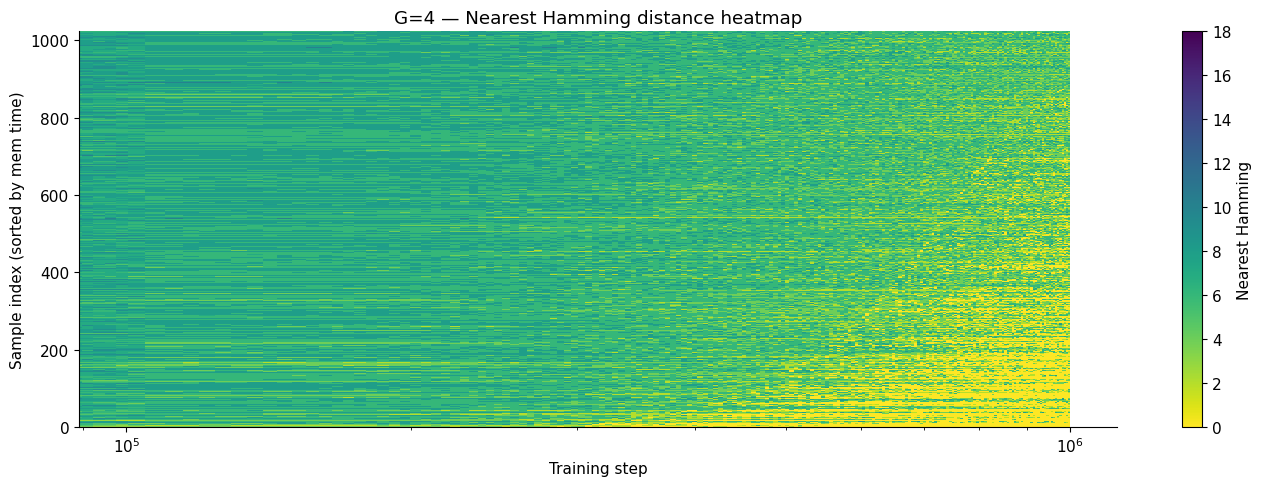

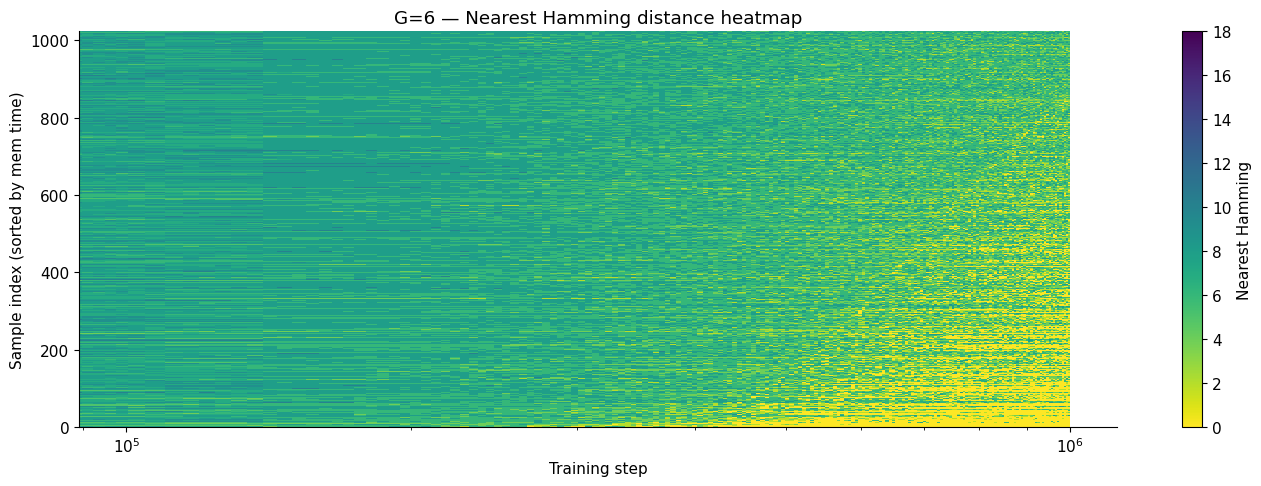

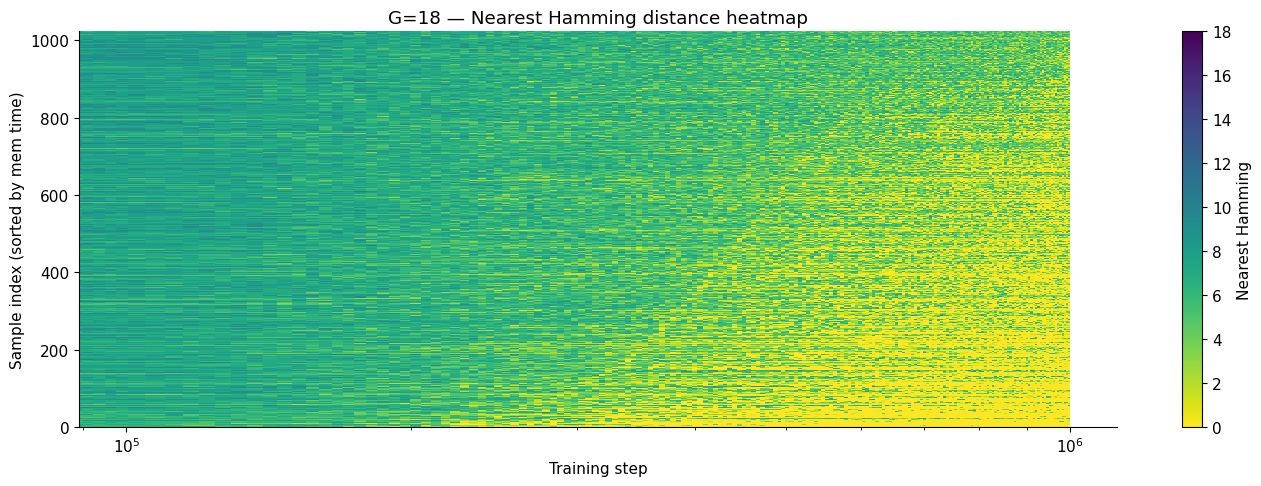

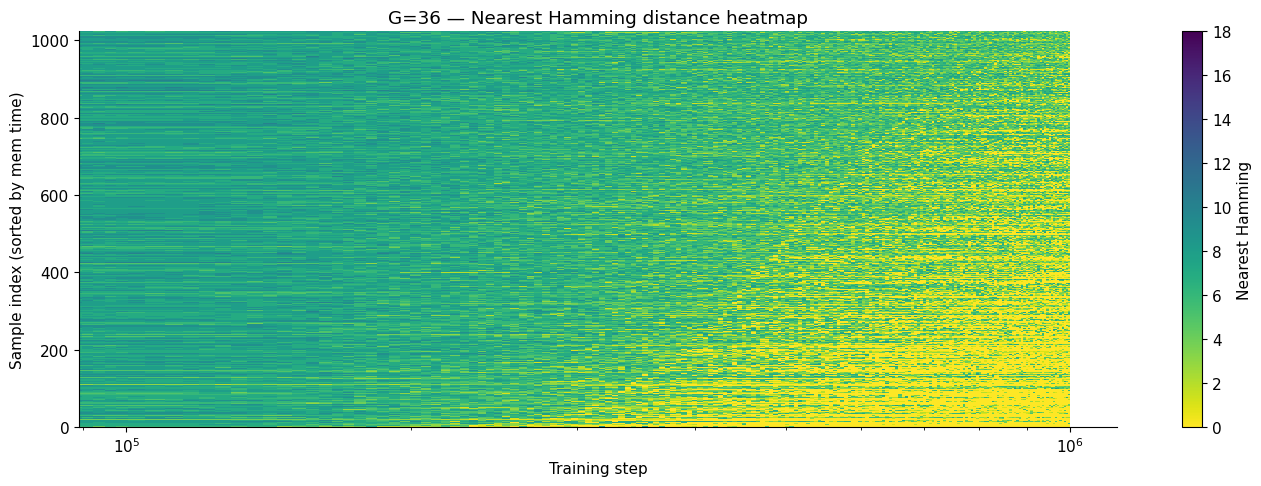

In [22]:
def hamming_heatmap(g, max_samples=1024):
    d = data[g]
    epochs_sub = d['epochs_sub']
    ham        = d['nearest_hamming']   # (T_sub, N)
    states     = d['traj_state']        # (N,)
    first_mem  = d['first_mem_ep']      # (N,)

    # Sort samples: mem first (by first_mem_ep asc), then novel, flicker, stuck
    sort_key = np.where(first_mem >= 0, first_mem.astype(float),
                        1e12 - states.astype(float) * 1e10)
    order = np.argsort(sort_key)

    # Subsample to max_samples evenly
    N = ham.shape[1]
    if N > max_samples:
        idx = np.linspace(0, N - 1, max_samples, dtype=int)
        order = order[idx]

    ham_sorted = ham[:, order].T   # (n_show, T_sub)

    fig, ax = plt.subplots(figsize=(14, 5))
    im = ax.pcolormesh(epochs_sub, np.arange(len(order)),
                        ham_sorted, cmap='viridis_r',
                        vmin=0, vmax=18)
    ax.set_xscale('log')
    ax.set_xlabel('Training step')
    ax.set_ylabel('Sample index (sorted by mem time)')
    ax.set_title(f'G={g} — Nearest Hamming distance heatmap')
    fig.colorbar(im, ax=ax, label='Nearest Hamming')
    fig.tight_layout()
    fig.savefig(f'{FIGDIR}/hamming_heatmap_G{g}.pdf', bbox_inches='tight')
    plt.show()


for g in [2, 3, 4, 6, 18, 36]:
    hamming_heatmap(g)

## Section 8: Correlation — early Hamming distance vs memorization time

For each G, compute Spearman correlation between early Hamming (first 10% of training)
and time-to-memorize (for memorized samples only).

G= 2: n_mem=1386  Spearman r=0.058  p=3.100e-02
G= 3: n_mem= 806  Spearman r=0.195  p=2.272e-08
G= 4: n_mem= 615  Spearman r=0.240  p=1.614e-09
G= 6: n_mem= 535  Spearman r=0.229  p=8.560e-08
G= 9: n_mem= 872  Spearman r=0.254  p=2.856e-14
G=12: n_mem= 734  Spearman r=0.204  p=2.442e-08
G=18: n_mem= 908  Spearman r=0.231  p=1.910e-12
G=36: n_mem= 763  Spearman r=0.239  p=2.245e-11


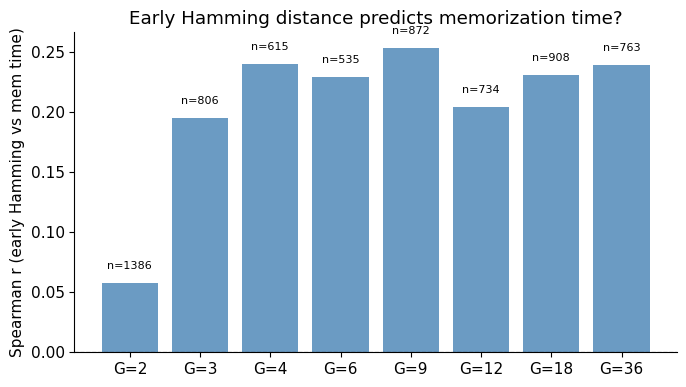

In [23]:
from scipy.stats import spearmanr

results = []
for g in GROUP_SIZES:
    d         = data[g]
    states    = d['traj_state']
    first_mem = d['first_mem_ep']
    early_ham = get_early_hamming(g, epoch_frac=0.1)

    mem_mask  = (states == 3) & (first_mem > 0)
    if mem_mask.sum() < 5:
        results.append((g, np.nan, np.nan, 0))
        continue

    ham_mem   = early_ham[mem_mask]
    time_mem  = first_mem[mem_mask]
    r, p      = spearmanr(ham_mem, time_mem)
    results.append((g, r, p, mem_mask.sum()))
    print(f'G={g:2d}: n_mem={mem_mask.sum():4d}  Spearman r={r:.3f}  p={p:.3e}')

# Plot
gs_vals  = [r[0] for r in results]
r_vals   = [r[1] for r in results]
n_vals   = [r[3] for r in results]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(len(gs_vals)), r_vals, color='steelblue', alpha=0.8)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xticks(range(len(gs_vals)))
ax.set_xticklabels([f'G={g}' for g in gs_vals])
ax.set_ylabel('Spearman r (early Hamming vs mem time)')
ax.set_title('Early Hamming distance predicts memorization time?')
for i, (r, n) in enumerate(zip(r_vals, n_vals)):
    if not np.isnan(r):
        ax.text(i, r + 0.01 * np.sign(r), f'n={n}', ha='center', va='bottom', fontsize=8)
fig.tight_layout()
fig.savefig(f'{FIGDIR}/spearman_early_hamming_vs_memtime.pdf', bbox_inches='tight')
plt.show()

In [32]:
states

array([1, 3, 1, ..., 3, 1, 1], dtype=uint8)

93520 238240 Interval: (0.4, 0.5) idx: 120 150
G= 2: n_mem=1386  Spearman r=0.353  p=7.201e-42
93520 238240 Interval: (0.4, 0.5) idx: 120 150
G= 3: n_mem= 806  Spearman r=0.293  p=1.891e-17
93520 238240 Interval: (0.4, 0.5) idx: 120 150
G= 4: n_mem= 615  Spearman r=0.327  p=8.321e-17
93520 238240 Interval: (0.4, 0.5) idx: 120 150
G= 6: n_mem= 535  Spearman r=0.258  p=1.384e-09
93520 238240 Interval: (0.4, 0.5) idx: 120 150
G= 9: n_mem= 872  Spearman r=0.478  p=6.578e-51
93520 238240 Interval: (0.4, 0.5) idx: 120 150
G=12: n_mem= 734  Spearman r=0.386  p=1.669e-27
93520 238240 Interval: (0.4, 0.5) idx: 120 150
G=18: n_mem= 908  Spearman r=0.481  p=7.366e-54
93520 238240 Interval: (0.4, 0.5) idx: 120 150
G=36: n_mem= 763  Spearman r=0.436  p=1.141e-36


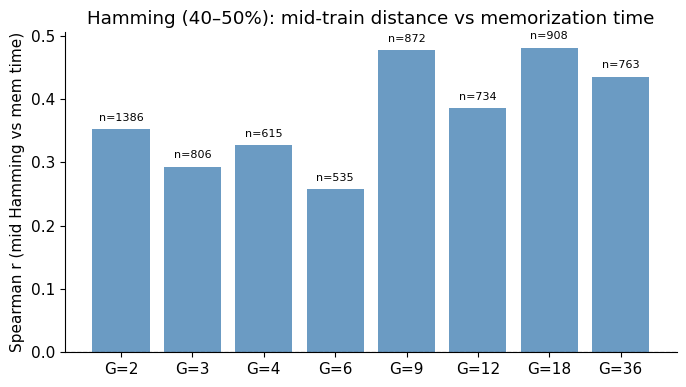

In [31]:
from scipy.stats import spearmanr

# Define the interval here for clarity and reproducibility
interval_frac = (0.4, 0.5)  # Mid-training interval (40%-50%)

results = []
for g in GROUP_SIZES:
    d         = data[g]
    states    = d['traj_state']
    first_mem = d['first_mem_ep']
    interval_ham = get_hamming_interval(g, epoch_interval=interval_frac)
    # epochs_sub = d['epochs_sub']

    mem_mask  = (states == 3) & (first_mem > 0)
    if mem_mask.sum() < 5:
        results.append((g, np.nan, np.nan, 0))
        continue

    ham_mem   = interval_ham[mem_mask]
    time_mem  = first_mem[mem_mask]
    r, p      = spearmanr(ham_mem, time_mem)
    results.append((g, r, p, mem_mask.sum()))
    print(f'G={g:2d}: n_mem={mem_mask.sum():4d}  Spearman r={r:.3f}  p={p:.3e}')

# Plot
gs_vals  = [r[0] for r in results]
r_vals   = [r[1] for r in results]
n_vals   = [r[3] for r in results]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(len(gs_vals)), r_vals, color='steelblue', alpha=0.8)
ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xticks(range(len(gs_vals)))
ax.set_xticklabels([f'G={g}' for g in gs_vals])
ax.set_ylabel('Spearman r (mid Hamming vs mem time)')
ax.set_title(
    f'Hamming ({int(interval_frac[0]*100)}–{int(interval_frac[1]*100)}%): ' +
    'mid-train distance vs memorization time'
)
for i, (r, n) in enumerate(zip(r_vals, n_vals)):
    if not np.isnan(r):
        ax.text(i, r + 0.01 * np.sign(r), f'n={n}', ha='center', va='bottom', fontsize=8)
fig.tight_layout()
fig.savefig(
    f'{FIGDIR}/spearman_hamming_{interval_frac[0]:.2f}_{interval_frac[1]:.2f}_vs_memtime.pdf',
    bbox_inches='tight'
)
plt.show()

## Section 9: Flickering analysis — why do some samples flicker?

For flickering samples: compare nearest Hamming trajectory and flicker score across G.

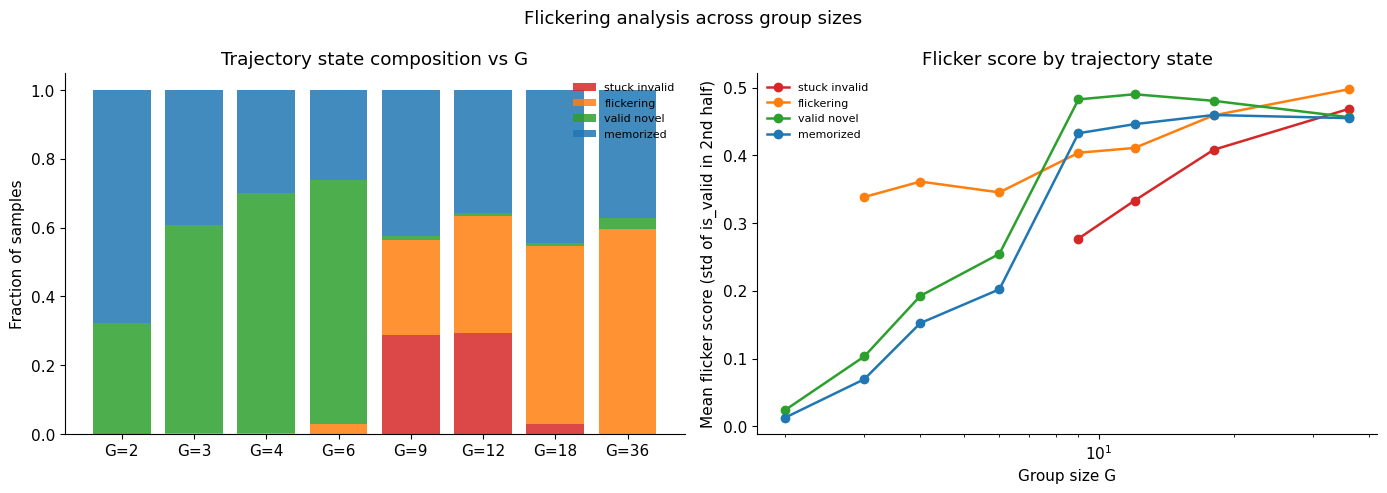

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: flickering fraction vs G
ax = axes[0]
fracs = {s: [] for s in range(4)}
for g in GROUP_SIZES:
    states = data[g]['traj_state']
    N = len(states)
    for s in range(4):
        fracs[s].append((states == s).sum() / N)

bottom = np.zeros(len(GROUP_SIZES))
x = np.arange(len(GROUP_SIZES))
for s in range(4):
    ax.bar(x, fracs[s], bottom=bottom, label=STATE_NAMES[s],
           color=STATE_COLORS[s], alpha=0.85)
    bottom += np.array(fracs[s])
ax.set_xticks(x)
ax.set_xticklabels([f'G={g}' for g in GROUP_SIZES])
ax.set_ylabel('Fraction of samples')
ax.set_title('Trajectory state composition vs G')
ax.legend(fontsize=8, frameon=False)

# Right: mean flicker score for flickering samples vs G
ax = axes[1]
for s in range(4):
    scores = []
    for g in GROUP_SIZES:
        states = data[g]['traj_state']
        mask   = states == s
        if mask.sum() > 0:
            scores.append(data[g]['flicker_score'][mask].mean())
        else:
            scores.append(np.nan)
    ax.plot(GROUP_SIZES, scores, 'o-', color=STATE_COLORS[s],
            label=STATE_NAMES[s], lw=1.8, ms=6)

ax.set_xlabel('Group size G')
ax.set_ylabel('Mean flicker score (std of is_valid in 2nd half)')
ax.set_title('Flicker score by trajectory state')
ax.legend(fontsize=8, frameon=False)
ax.set_xscale('log')

fig.suptitle('Flickering analysis across group sizes', fontsize=13)
fig.tight_layout()
fig.savefig(f'{FIGDIR}/flickering_analysis.pdf', bbox_inches='tight')
plt.show()

## Section 10: Summary — nearest-training-sample identity

For memorized samples: which training samples are most 'magnetic' (attract the most noise seeds)?

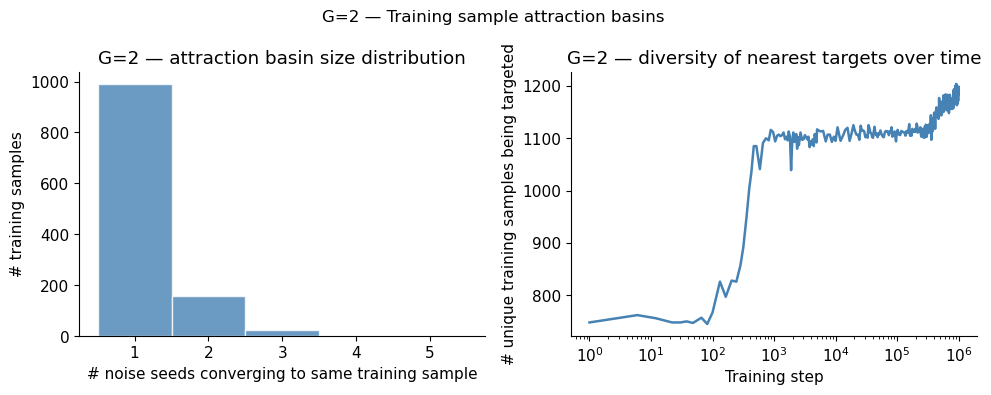

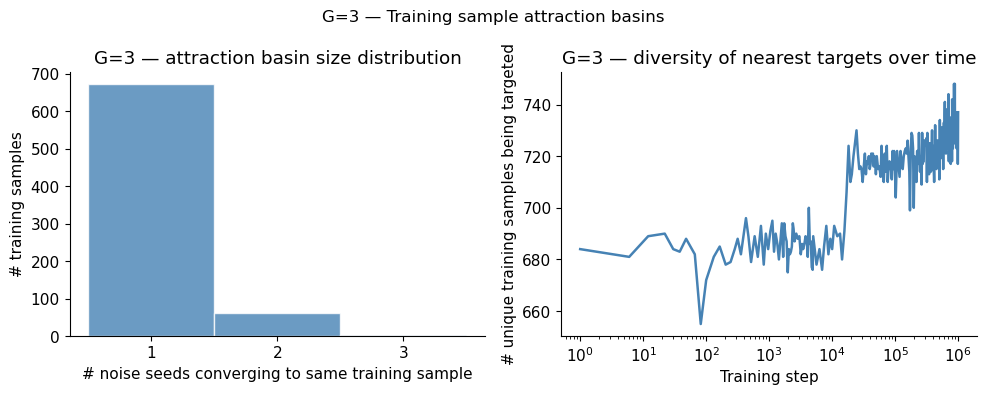

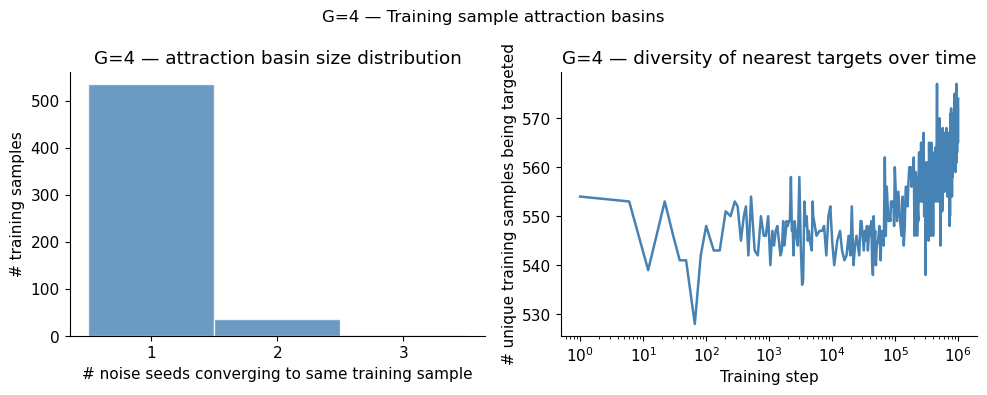

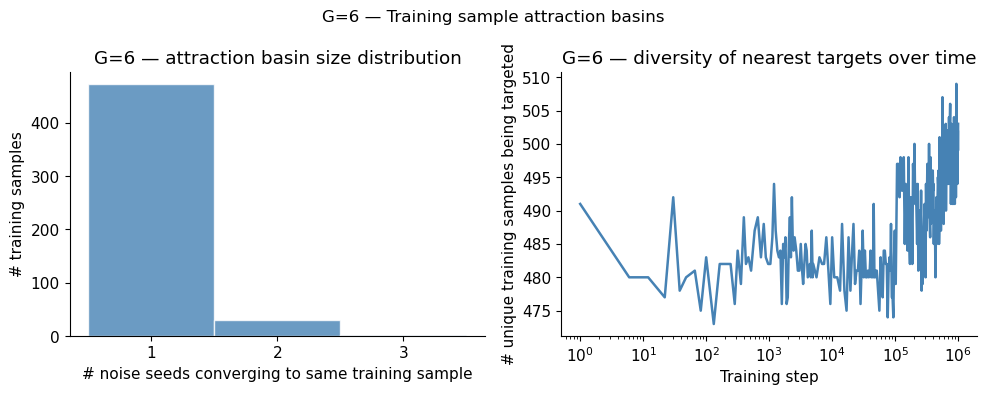

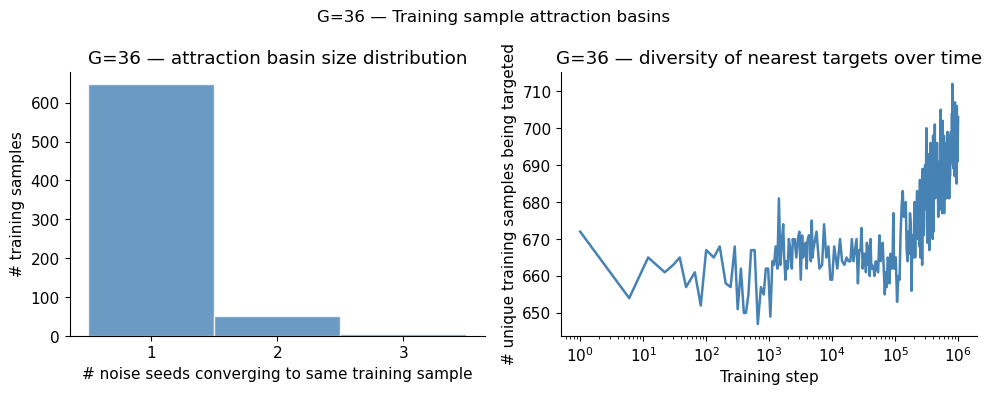

In [ ]:
def plot_attraction_basin(g, final_frac=0.1):
    """Show how many sample slots converge to each training example."""
    d = data[g]
    epochs_sub   = d['epochs_sub']
    T_sub        = len(epochs_sub)
    nearest_idx  = d['nearest_idx_ham']   # (T_sub, N) -> index in training set
    states       = d['traj_state']         # (N,)
    N_train      = int(d['N_train'])

    # At final checkpoint: count how many samples converge to each training sample
    final_idx = nearest_idx[-1]            # (N,)
    mem_mask  = states == 3

    counts = np.bincount(final_idx[mem_mask], minlength=N_train)  # (N_train,)
    nonzero = counts[counts > 0]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Distribution of basin sizes
    ax = axes[0]
    max_basin = nonzero.max() if len(nonzero) > 0 else 1
    ax.hist(nonzero, bins=np.arange(0.5, max_basin + 1.5),
            color='steelblue', alpha=0.8, edgecolor='white')
    ax.set_xlabel('# noise seeds converging to same training sample')
    ax.set_ylabel('# training samples')
    ax.set_title(f'G={g} — attraction basin size distribution')
    # Set integer xticks only
    ax.set_xticks(np.arange(1, max_basin + 1))
    ax.xaxis.set_major_formatter('{:d}'.format)

    # Over time: how many unique training samples are "targeted"?
    ax = axes[1]
    n_unique = [len(set(nearest_idx[t, mem_mask].tolist()))
                for t in range(T_sub)]
    ax.plot(epochs_sub, n_unique, color='steelblue', lw=1.8)
    ax.set_xscale('log')
    ax.set_xlabel('Training step')
    ax.set_ylabel('# unique training samples being targeted')
    ax.set_title(f'G={g} — diversity of nearest targets over time')

    fig.suptitle(f'G={g} — Training sample attraction basins', fontsize=12)
    fig.tight_layout()
    fig.savefig(f'{FIGDIR}/attraction_basin_G{g}.pdf', bbox_inches='tight')
    plt.show()


for g in [2, 3, 4, 6, 36]:
    plot_attraction_basin(g)